In [ ]:
import novae

In [2]:
import scanpy as sc

DATA_PATH="./SEAAD_train.h5ad"
adata_t = sc.read_h5ad(DATA_PATH)

In [3]:
adata_t

AnnData object with n_obs × n_vars = 1510183 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months', 'APOE4 Status', 'Primary Study Name', 'Secondary Study Name', 

/tmp/ipykernel_2100313/231786398.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_t, color='Class', spot_size=10)


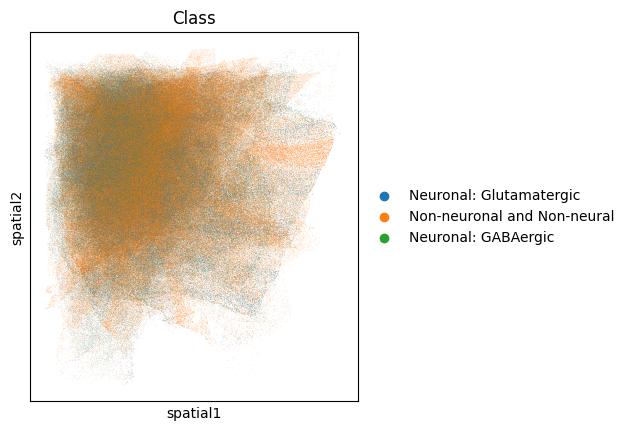

In [6]:
#sc.pl.spatial(adata_t,color="Subclass")
sc.pl.spatial(adata_t, color='Class', spot_size=10)

In [4]:
DATA_PATH="./SEAAD_test.h5ad"
adata_test = sc.read_h5ad(DATA_PATH)

In [6]:
novae.spatial_neighbors(adata_t, radius=10)

[INFO] (novae.utils.build) Computing graph on 1,510,183 cells (coord_type=generic, delaunay=True, radius=[0.0, 10.0], n_neighs=None)


In [7]:
model = novae.Novae.from_pretrained("MICS-Lab/novae-human-0")
model.fine_tune(adata_t,max_epochs=1)
model.compute_representations(adata_t)

[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


Computing representations:   0%|          | 0/196 [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/roxana/anaconda3/envs/omnist/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | cell_embedder | CellEmbedder      | 31.3 M | train
1 | encoder       | GraphEncoder      | 694 K  | train
2 | augmentation  | GraphAugmentation | 0      | train
3 | swav_head     | SwavHead          | 32.8 K | train
------------------------------------------------------------
989 K     Trainable params
31.1 M    Non-trainable params
32.1 M    Total params
128.266   Total estimated model params size (MB)
82        Modules in train mode
0         Modules in eval mode
/home/roxana/anaconda3/envs/omnist/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


Computing representations:   0%|          | 0/2368 [00:00<?, ?it/s]

In [8]:
novae.spatial_neighbors(adata_test, radius=10)

[INFO] (novae.utils.build) Computing graph on 377,546 cells (coord_type=generic, delaunay=True, radius=[0.0, 10.0], n_neighs=None)
[WARNING] (novae.utils.build) The mean number of neighbors is 1.5994130516546328, which is very low. Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.


In [9]:
model.fine_tune(adata_test,max_epochs=1)
model.compute_representations(adata_test)

[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])
[WARNING] (novae.data.dataset) Only 53.05% of the cells have a valid neighborhood.
Consider running `novae.spatial_neighbors` with a larger `radius`.


Computing representations:   0%|          | 0/196 [00:00<?, ?it/s]

[WARNING] (novae.data.dataset) Only 53.05% of the cells have a valid neighborhood.
Consider running `novae.spatial_neighbors` with a larger `radius`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/roxana/anaconda3/envs/omnist/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | cell_embedder | CellEmbedder      | 31.3 M | train
1 | encoder       | GraphEncoder      | 694 K  | train
2 | augmentation  | GraphAugmentation | 0      | train
3 | swav_head     | SwavHead          | 32.8 K | train
------------------------------------------------------------
989 K     Trainable params
31.1 M    Non-trainable params
32.1 M    Total params
128.266   Total estimated model params size (MB)
82        Modules i

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.
[WARNING] (novae.data.dataset) Only 53.05% of the cells have a valid neighborhood.
Consider running `novae.spatial_neighbors` with a larger `radius`.


Computing representations:   0%|          | 0/392 [00:00<?, ?it/s]

In [10]:
import numpy as np
np.save("emb_train.npy",adata_t.obsm["novae_latent"])
np.save("emb_test.npy",adata_test.obsm["novae_latent"])

In [5]:
import numpy as np
adata_t.obsm["novae_latent"]=np.load("emb_train.npy")
adata_test.obsm["novae_latent"]=np.load("emb_test.npy")

In [6]:
X_train = np.array(adata_t.obsm["novae_latent"])
X_test = np.array(adata_test.obsm["novae_latent"])

In [7]:
set(adata_test.obs["Subclass"]) - set(adata_t.obs["Subclass"])


set()

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(adata_t.obs["Subclass"])
y_test = le.transform(adata_test.obs["Subclass"])

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ==== Convert to tensors ====
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

device =  "cpu"

# ==== Compute class weights ====
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ==== Build dataset and balanced sampler ====
train_dataset = TensorDataset(X_train_t, y_train_t)
class_sample_counts = np.bincount(y_train)
weights_per_sample = 1.0 / class_sample_counts[y_train]
sampler = WeightedRandomSampler(weights_per_sample, len(weights_per_sample))

train_loader = DataLoader(train_dataset, batch_size=512, sampler=sampler)

# ==== Define MLP ====
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.fc(x)

input_dim = X_train.shape[1]
num_classes = len(classes)
model = MLPClassifier(input_dim, num_classes).to(device)

# ==== Optimiser and loss ====
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-1)
epochs = 100

# ==== Training loop ====
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

print("✅ Training complete!")


Epoch 10/100, Loss: 2.5772
Epoch 20/100, Loss: 2.5782
Epoch 30/100, Loss: 2.5785
Epoch 40/100, Loss: 2.5789
Epoch 50/100, Loss: 2.5776
Epoch 60/100, Loss: 2.5778
Epoch 70/100, Loss: 2.5774
Epoch 80/100, Loss: 2.5805
Epoch 90/100, Loss: 2.5770
Epoch 100/100, Loss: 2.5795
✅ Training complete!


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report,roc_auc_score

model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_test_t.to(device)), dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average="macro")
recall = recall_score(y_test, preds, average="macro")
f1 = f1_score(y_test, preds, average="macro")
y_true_bin = np.eye(num_classes)[y_test]
pr_auc = average_precision_score(y_true_bin, probs, average="macro")
roc_auc=roc_auc_score(y_true_bin, probs, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")

print("\nPer-class metrics:")
print(classification_report(y_test, preds, target_names=le.classes_))


/home/roxana/anaconda3/envs/omnist/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.0038
Precision (macro): 0.0270
Recall (macro): 0.0423
F1-score (macro): 0.0026
PR-AUC (macro): 0.0418
ROC-AUC (macro): 0.5027

Per-class metrics:
                 precision    recall  f1-score   support

      Astrocyte       0.00      0.00      0.00     42305
     Chandelier       0.00      0.97      0.00       905
    Endothelial       0.11      0.00      0.00     15364
        L2/3 IT       0.00      0.00      0.00     34243
          L4 IT       0.00      0.00      0.00     19462
          L5 ET       0.00      0.00      0.00      1339
          L5 IT       0.00      0.00      0.00     18187
        L5/6 NP       0.00      0.00      0.00      2496
          L6 CT       0.00      0.00      0.00      4821
          L6 IT       0.00      0.00      0.00     12603
     L6 IT Car3       0.00      0.00      0.00      7299
            L6b       0.00      0.00      0.00      6686
          Lamp5       0.00      0.00      0.00      4220
     Lamp5 Lhx6       0.00      0.00      0

/home/roxana/anaconda3/envs/omnist/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/roxana/anaconda3/envs/omnist/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/roxana/anaconda3/envs/omnist/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [15]:
import torch.nn as nn
import torch.optim as optim

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128, dropout=0.1):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.fc(x)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))
model = MLPClassifier(input_dim, num_classes)


In [16]:
import torch

device =  "cpu"
model.to(device)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 1000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 1/1000, Loss: 3.1990
Epoch 2/1000, Loss: 3.0133
Epoch 3/1000, Loss: 2.8501
Epoch 4/1000, Loss: 2.7578
Epoch 5/1000, Loss: 2.7531
Epoch 6/1000, Loss: 2.7211
Epoch 7/1000, Loss: 2.6692
Epoch 8/1000, Loss: 2.6254
Epoch 9/1000, Loss: 2.5915
Epoch 10/1000, Loss: 2.5572
Epoch 11/1000, Loss: 2.5215
Epoch 12/1000, Loss: 2.4876
Epoch 13/1000, Loss: 2.4574
Epoch 14/1000, Loss: 2.4312
Epoch 15/1000, Loss: 2.4089
Epoch 16/1000, Loss: 2.3896
Epoch 17/1000, Loss: 2.3726
Epoch 18/1000, Loss: 2.3579
Epoch 19/1000, Loss: 2.3462
Epoch 20/1000, Loss: 2.3383
Epoch 21/1000, Loss: 2.3340
Epoch 22/1000, Loss: 2.3325
Epoch 23/1000, Loss: 2.3331
Epoch 24/1000, Loss: 2.3349
Epoch 25/1000, Loss: 2.3366
Epoch 26/1000, Loss: 2.3369
Epoch 27/1000, Loss: 2.3353
Epoch 28/1000, Loss: 2.3319
Epoch 29/1000, Loss: 2.3271
Epoch 30/1000, Loss: 2.3218
Epoch 31/1000, Loss: 2.3167
Epoch 32/1000, Loss: 2.3127
Epoch 33/1000, Loss: 2.3098
Epoch 34/1000, Loss: 2.3077
Epoch 35/1000, Loss: 2.3060
Epoch 36/1000, Loss: 2.3046
E

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report
)
import numpy as np
import torch

# --- Get predictions and probabilities ---
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    pred_labels = np.argmax(probs, axis=1)

# --- Compute metrics ---
accuracy = accuracy_score(y_test, pred_labels)
precision = precision_score(y_test, pred_labels, average="macro")
recall = recall_score(y_test, pred_labels, average="macro")
macro_f1 = f1_score(y_test, pred_labels, average="macro")

# --- Compute macro PR-AUC ---
# Convert true labels to one-hot for multiclass PR-AUC
y_true_bin = np.eye(len(np.unique(y_test)))[y_test]
pr_auc = average_precision_score(y_true_bin, probs, average="macro")

# --- Print results ---
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {macro_f1:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}\n")

# --- Per-class breakdown ---
print(classification_report(y_test, pred_labels, target_names=le.classes_))



/home/roxana/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.3024
Precision (macro): 0.0908
Recall (macro): 0.0462
F1-score (macro): 0.0302
PR-AUC (macro): 0.0457

                 precision    recall  f1-score   support

      Astrocyte       0.37      0.01      0.02     42305
     Chandelier       0.00      0.00      0.00       905
    Endothelial       0.09      0.02      0.03     15364
        L2/3 IT       0.12      0.01      0.01     34243
          L4 IT       0.09      0.03      0.04     19462
          L5 ET       0.00      0.00      0.00      1339
          L5 IT       0.09      0.01      0.02     18187
        L5/6 NP       0.02      0.02      0.02      2496
          L6 CT       0.05      0.00      0.00      4821
          L6 IT       0.00      0.00      0.00     12603
     L6 IT Car3       0.00      0.00      0.00      7299
            L6b       0.07      0.00      0.01      6686
          Lamp5       0.05      0.00      0.00      4220
     Lamp5 Lhx6       0.07      0.00      0.00      3289
  Microglia-PVM       0.23   

/home/roxana/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/roxana/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/roxana/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
data = adata_test.copy()
sc.pp.filter_genes(data, min_cells=3) 

 

sc.pp.highly_variable_genes( data, flavor="cell_ranger", n_top_genes=2000 )# drop batch_key if single batch ) 

data = data[:, data.var['highly_variable']].copy() 

 

# Scale data (optional) 

sc.pp.scale(data) 

 

# Perform PCA (optional, for dimensionality reduction before UMAP) 

sc.tl.pca(data, svd_solver='arpack') 

 

sc.pp.neighbors(data, use_rep='X_pca', random_state=42) 

In [23]:
sc.tl.umap(data, random_state=42) 
data.obs["Predictions"] = le.inverse_transform(pred_labels)
 

# --- Plot --- 


/home/roxana/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/roxana/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


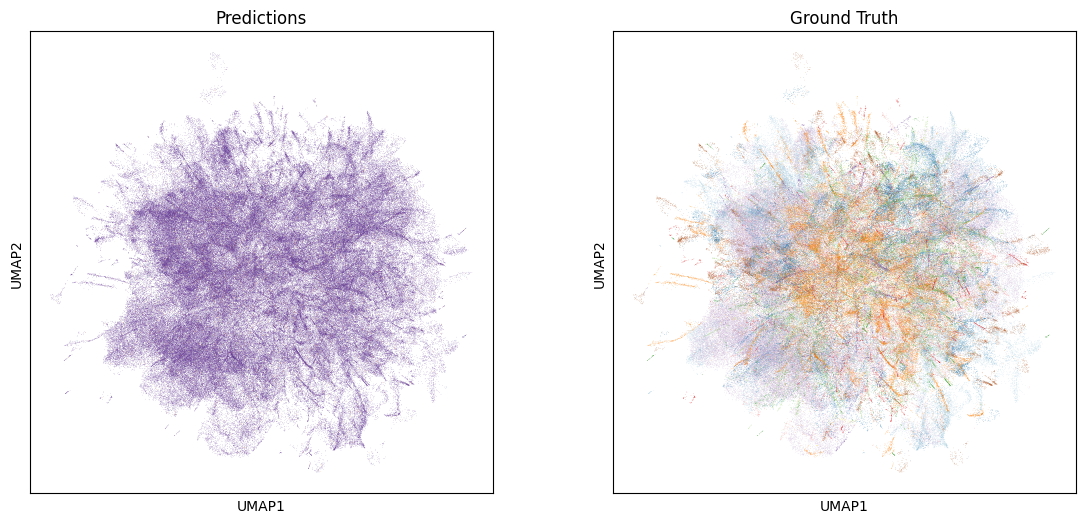

In [24]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6) 

fig = sc.pl.umap( data, 
color=['Predictions', 'Subclass'], 
palette='Paired', 
title=['Predictions', 'Ground Truth'], 
show=False, 
return_fig=True ) 

 

# --- Combine legends into one --- 

handles, labels = [], [] 

for ax in fig.axes:
    h, l = ax.get_legend_handles_labels() 
    handles.extend(h) 
    labels.extend(l) 
    ax.get_legend().remove() 

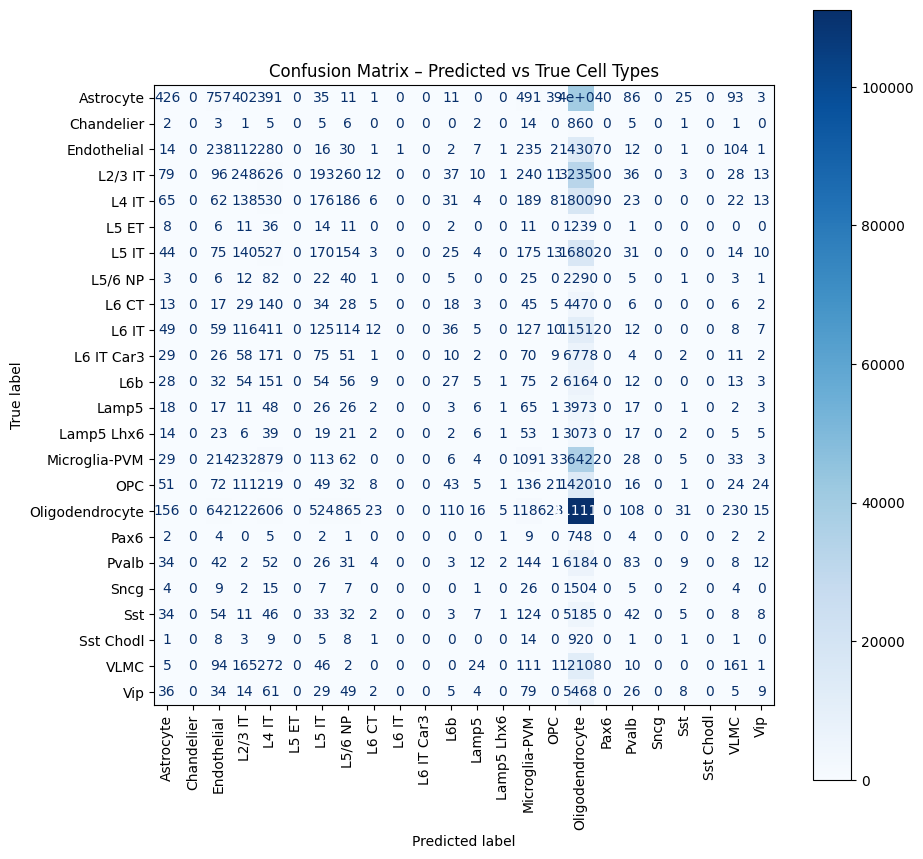

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues', colorbar=True)
plt.title("Confusion Matrix – Predicted vs True Cell Types")
plt.show()


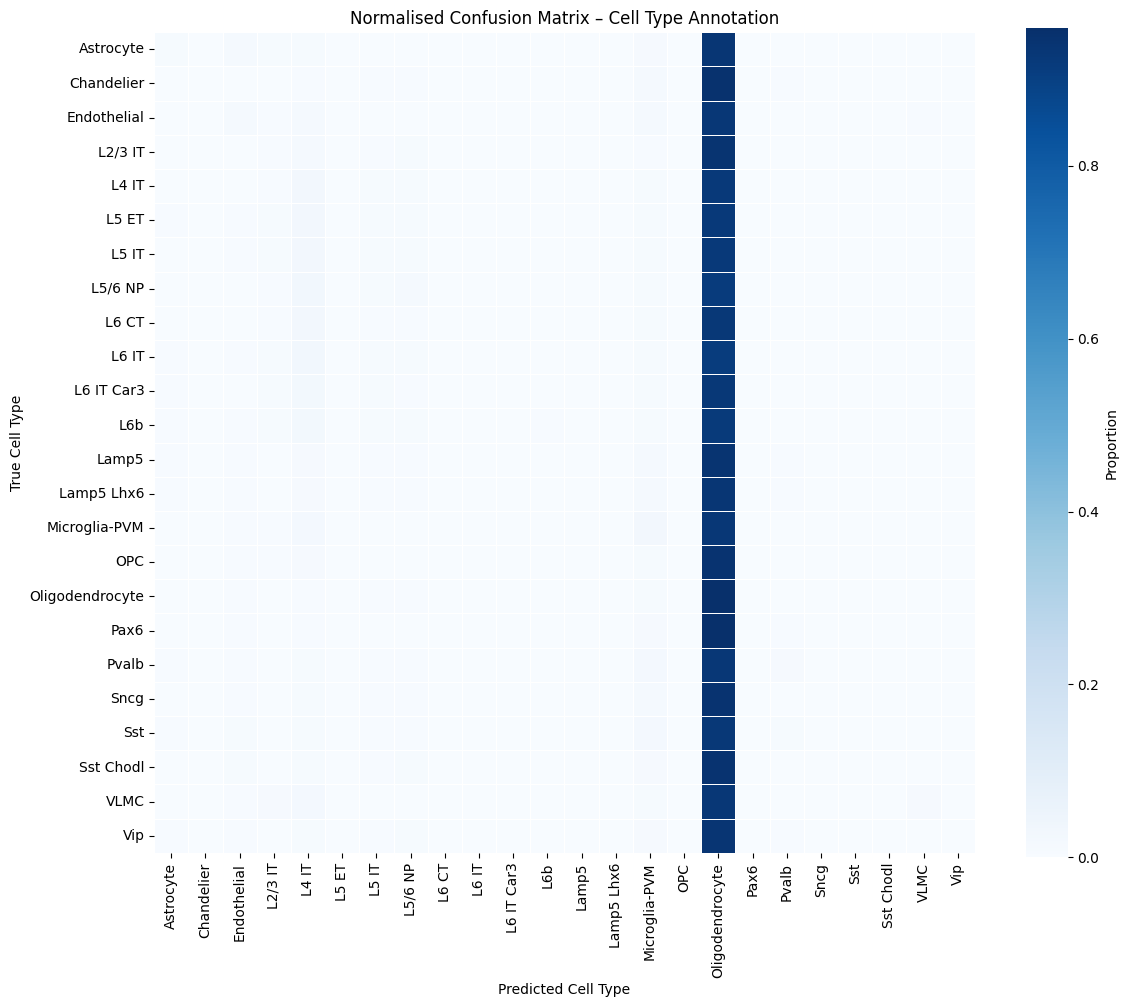

In [19]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute normalised confusion matrix (per true label)
cm = confusion_matrix(y_test, pred_labels, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_,
            square=True, cbar_kws={'label': 'Proportion'}, linewidths=0.5)
plt.xlabel("Predicted Cell Type")
plt.ylabel("True Cell Type")
plt.title("Normalised Confusion Matrix – Cell Type Annotation")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
